In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
from smooth_POD_ROM.initial_conditions import rectangular_pulse
from smooth_POD_ROM.reduced_order_model import make_training_data, make_test_data, train_ROM_rw, get_data_rw, L2_error_rw, get_predictions, optimize_hyperparameters, get_improvement, target_function

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [5]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 15,  # 25
    "g": rectangular_pulse, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "mode": "wrap",
    "sigma": 0.0578,

    "c": 2,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [6]:
mu_train, X_train, X_train_s = make_training_data(case)


my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

In [7]:
mu_test = [[0.15], [0.175], [0.2]]
X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

X_test, X_test_s = get_data_rw(mu=mu_test, **case)

e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:68: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


In [8]:
caseQ = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 25,
    "n_test": 15,  # 25
    "g": rectangular_pulse, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "mode": "wrap",
    "sigma": 0.0578,

    "c": 2,
    "monitor_progress_postprocessing": False,
    "num_iter": 25,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}
mu_trainQ, X_trainQ, _ = make_training_data(caseQ)

In [45]:
# -------------------------------------------------------------------------
# Quadratic-manifold ROM trained on the same X_train and evaluated at mu_test
# -------------------------------------------------------------------------

def train_quadratic_manifold(mu_train, X_train, r=10, reg=1e-8):
    """
    X_train shape: (n_snapshots, n_x)
    mu_train shape: (n_snapshots, parameter_dim)
    """
    print(mu_train.shape, X_train.shape)

    mu_train = np.asarray(mu_train, dtype=float).reshape(len(mu_train), -1)
    X_train = np.asarray(X_train, dtype=float)
    print(mu_train.shape, X_train.shape)

    n_snapshots, n_x = X_train.shape

    # Because of mean-centering, rank <= n_snapshots - 1
    r = min(r, n_snapshots - 1)

    x_mean = np.mean(X_train, axis=0)
    Xc = X_train - x_mean

    U, S, Vt = svd(Xc, full_matrices=False)
    V = Vt[:r, :].T                      # shape: (n_x, r)

    # Reduced training coordinates
    A_train = Xc @ V                      # shape: (n_snapshots, r)

    # Linear reconstruction residual
    X_lin_train = A_train @ V.T + x_mean
    R_train = X_train - X_lin_train       # shape: (n_snapshots, n_x)

    # Quadratic features: a_i a_j for j <= i
    ii, jj = np.tril_indices(r)

    def feature_map(A):
        A = np.asarray(A)
        return A[:, ii] * A[:, jj]        # shape: (n_snapshots, r(r+1)/2)

    F_train = feature_map(A_train)

    # Ridge-regularized least-squares fit:
    # F_train @ W ≈ R_train
    q = F_train.shape[1]
    W = np.linalg.solve(
        F_train.T @ F_train + reg * np.eye(q),
        F_train.T @ R_train
    )                                     # shape: (q, n_x)

    # Interpolate reduced coordinates mu -> a(mu)

    mu_1d = mu_train[:, 0]
    order = np.argsort(mu_1d)

    coord_interpolators = [
        interp1d(
            mu_1d[order],
            A_train[order, k],
            kind="linear",
            fill_value="extrapolate"
        )
        for k in range(r)
    ]

    def predict_reduced(mu):
        mu = np.asarray(mu, dtype=float).reshape(len(mu), -1)
        return np.column_stack([
            interp(mu[:, 0]) for interp in coord_interpolators
        ])


    def predict(mu):
        A = predict_reduced(mu)
        F = feature_map(A)

        X_lin = A @ V.T + x_mean
        X_quad = F @ W

        return X_lin + X_quad

    return predict, V, W


qrom_rank = 4

predict_QROM, V_QROM, W_QROM = train_quadratic_manifold(
    mu_trainQ,
    X_trainQ,
    r=qrom_rank,
    reg=1e-8
)

X_test_QROM = predict_QROM(mu_test)
e_QROM = L2_error_rw(X_test_QROM, X_test)

(25, 1) (25, 1000)
(25, 1) (25, 1000)


NameError: name 'mu_trainQ' is not defined

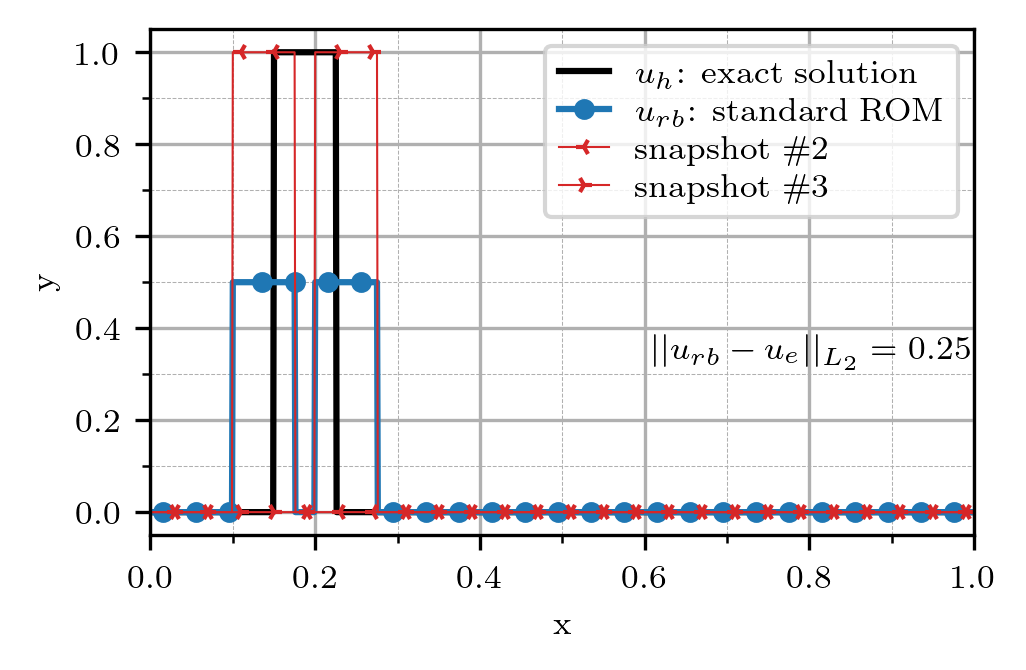

In [46]:
fig, ax = plt.subplots()
plt.plot(x, X_test[0], "k-", ms=4, markevery=(0, markevery), label=r"$u_h$: exact solution")
plt.plot(x, X_test_ROM[0], "C0o-", ms=4, markevery=(15, markevery), label=r"$u_{rb}$: standard ROM")
plt.plot(x, X_train[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"snapshot \#2")
plt.plot(x, X_train[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"snapshot \#3")

ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="upper right")
#e = np.mean((bump(x, 0.35)-X_intp[:, 0])**2)**.5
ax.text(1, 0.35, r"$||u_{rb}-u_e||_{L_2}"+"={:.2f}$".format(e_ROM[0]), horizontalalignment='right', verticalalignment='center')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.savefig(pth+"standard_ROM.pdf", bbox_inches='tight')
plt.show()

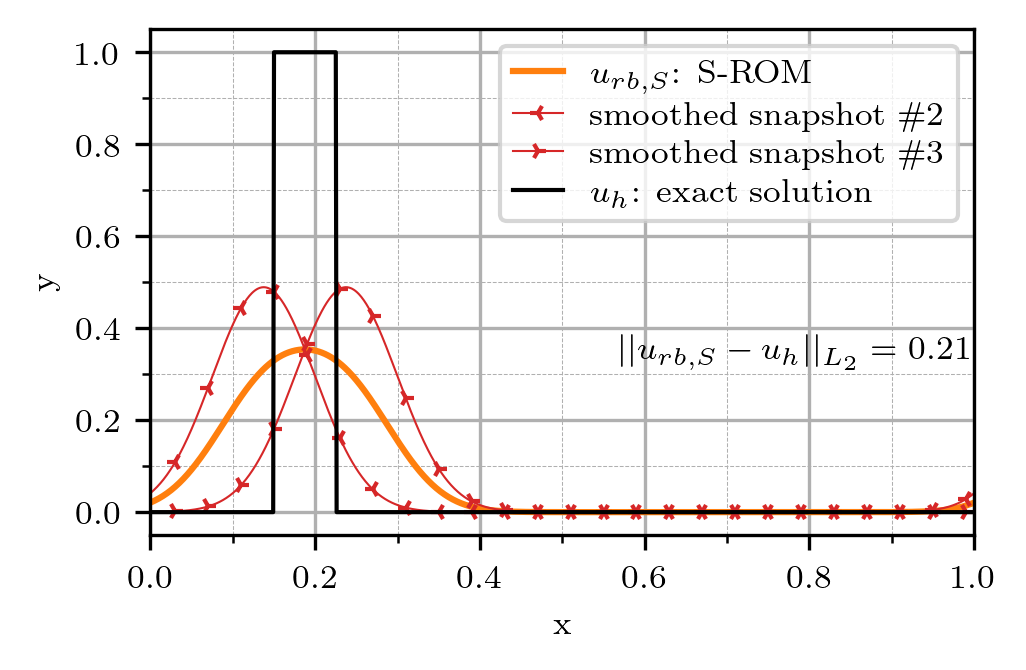

In [47]:
fig, ax = plt.subplots()
plt.plot(x, X_test_sROM[0], "C1", ms=4, markevery=(15, markevery), label=r"$u_{rb, S}$: S-ROM")
plt.plot(x, X_train_s[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#2")
plt.plot(x, X_train_s[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#3")
plt.plot(x, X_test[0], "k-", ms=4, lw=1, markevery=(0, markevery), label=r"$u_h$: exact solution")

ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="upper right")
ax.text(1, 0.35, r"$||u_{rb,S}-u_h||_{L_2}"+"={:.2f}$".format(e_sROM[0]), horizontalalignment='right', verticalalignment='center')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.savefig(pth+"convolution_ROM.pdf", bbox_inches='tight')
plt.show()

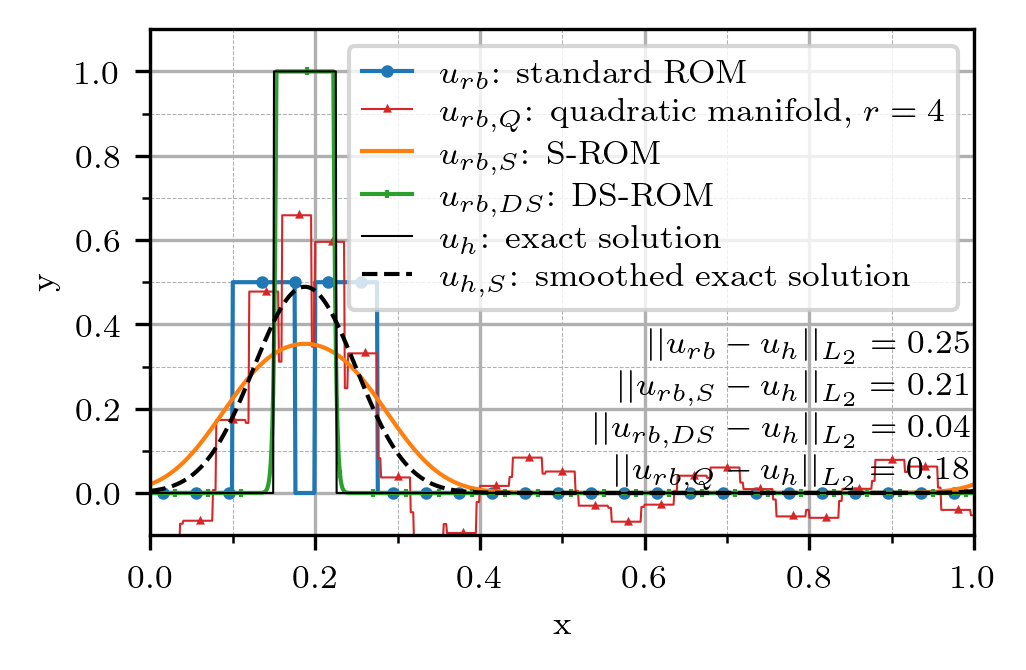

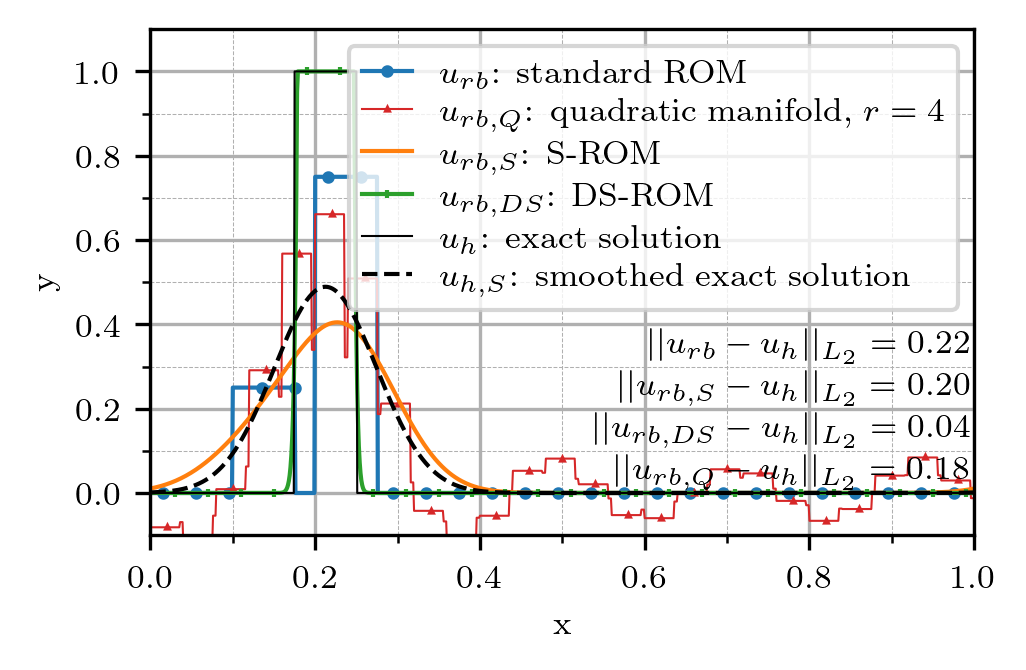

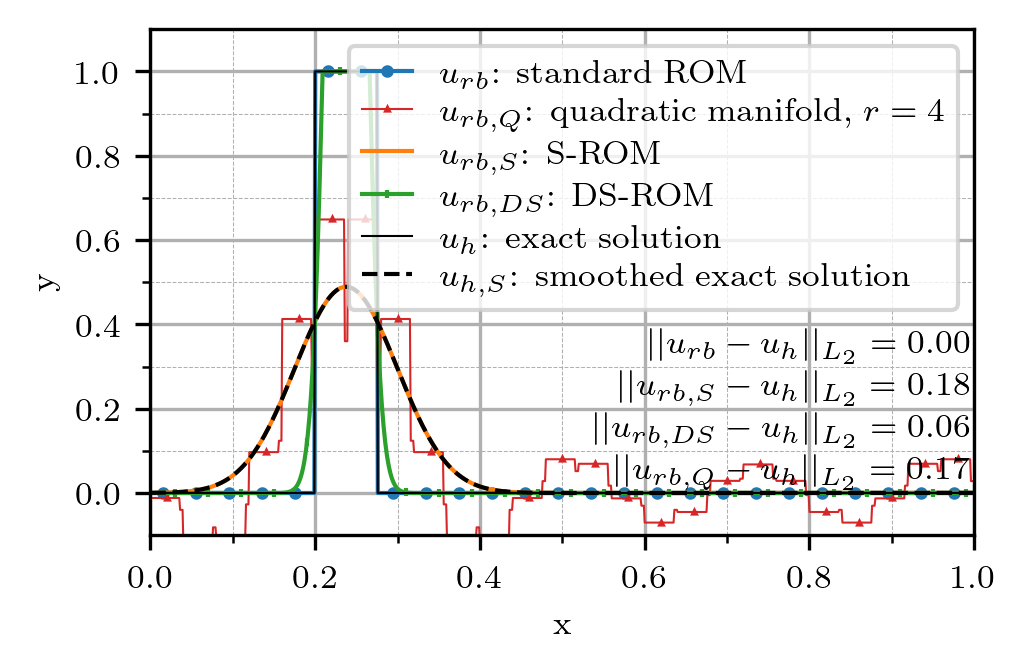

In [49]:
for ss in [0, 1, 2]:
    fig, ax = plt.subplots()
    ax.plot(x, X_test_ROM[ss, :], "C0o-", ms=2, lw=1, markevery=(15, markevery), label=r"$u_{rb}$: standard ROM")
    ax.plot(x,  X_test_QROM[ss, :], "C3^-", ms=.5, lw=.5, markevery=(20, markevery), label=rf"$u_{{rb, Q}}$: quadratic manifold, $r={qrom_rank}$")
    ax.plot(x, X_test_sROM[ss, :], "C1", ms=2, lw=1, label=r"$u_{rb, S}$: S-ROM")
    ax.plot(x, X_test_sROMs[ss, :], "C2|-", ms=2, lw=1, markevery=(30, markevery), label=r"$u_{rb, DS}$: DS-ROM")
    ax.plot(x, X_test[ss, :], "k-", ms=3, lw=.5, markevery=(0, markevery), label=r"$u_h$: exact solution")
    ax.plot(x, X_test_s[ss, :], "k--", ms=3, lw=1, markevery=(0, markevery), label=r"$u_{h,S}$: smoothed exact solution")
    # plt.plot(x, X_test[0], "kx-", ms=4, markevery=(0, markevery), label=r"$u_e$: exact solution")
    # plt.plot(x, X_test_sROM[0], "C1--", ms=4, markevery=(15, markevery), label=r"$u_{rb, S}$: S-ROM")
    # plt.plot(x, X_train[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#2")
    # plt.plot(x, X_train[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#3")
    
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend(loc="upper right")
    ax.text(0.999, 0.35, r"$||u_{rb}-u_h||_{L_2}"+"={:.2f}$".format(e_ROM[ss]), horizontalalignment='right', verticalalignment='center')
    ax.text(0.999, 0.25, r"$||u_{rb, S}-u_h||_{L_2}"+"={:.2f}$".format(e_sROM[ss]), horizontalalignment='right', verticalalignment='center')
    ax.text(0.999, 0.15, r"$||u_{rb, DS}-u_h||_{L_2}"+"={:.2f}$".format(e_sROMs[ss]), horizontalalignment='right', verticalalignment='center')
    ax.text(0.999,  0.05, r"$||u_{rb, Q}-u_h||_{L_2}" + "={:.2f}$".format(e_QROM[ss]), horizontalalignment='right', verticalalignment='center')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 1)
    plt.ylim(-.1, 1.1)
    plt.savefig(pth+"comparison_approaches{:.0f}.pdf".format(ss+1), bbox_inches='tight')
    plt.show()

In [9]:
case["n_test"] = 25
n_val = 500

10
mean ROM: 0.192001
mean esROM: 0.196510 (-2.3488%)
mean esROMs: 0.040759 (78.7714%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05783333, 1.88888889, 0.19080839, 0.19723261, 0.04432817, -76.7682
mean ROM: 0.190808
mean esROM: 0.197233 (-2.3488%)
mean esROMs: 0.044328 (78.7714%)


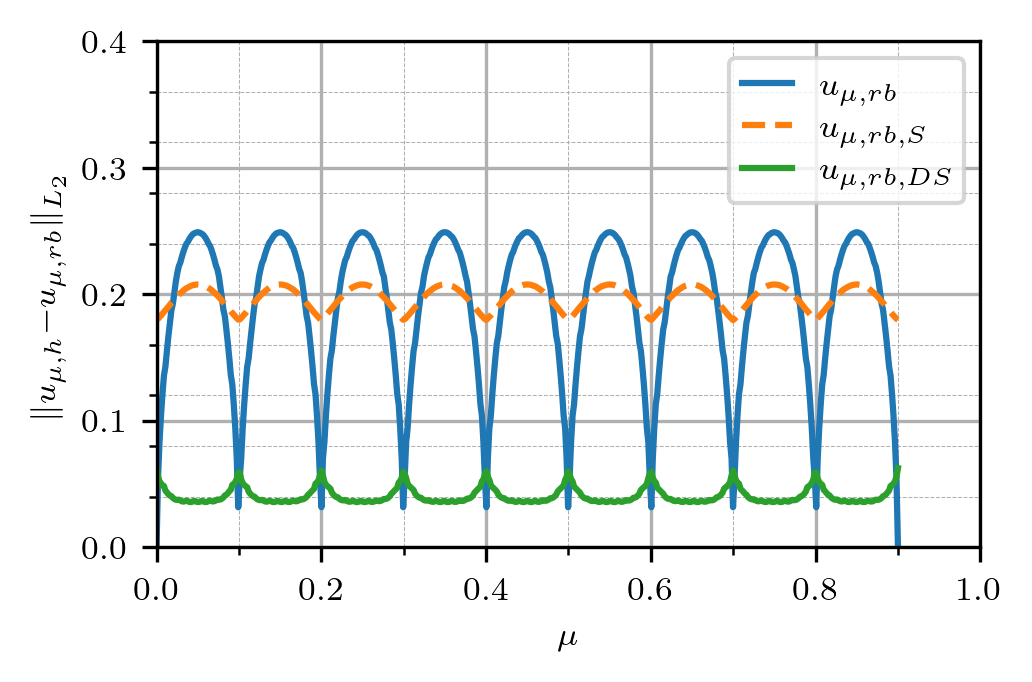

mean ROM: 0.056110
mean esROM: 0.179627 (-220.1359%)
mean esROMs: 0.035650 (36.4640%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.05783333, 1.88888889, 0.05500465, 0.17972839, 0.03694575, -32.8316
mean ROM: 0.055005
mean esROM: 0.179728 (-220.1359%)
mean esROMs: 0.036946 (36.4640%)


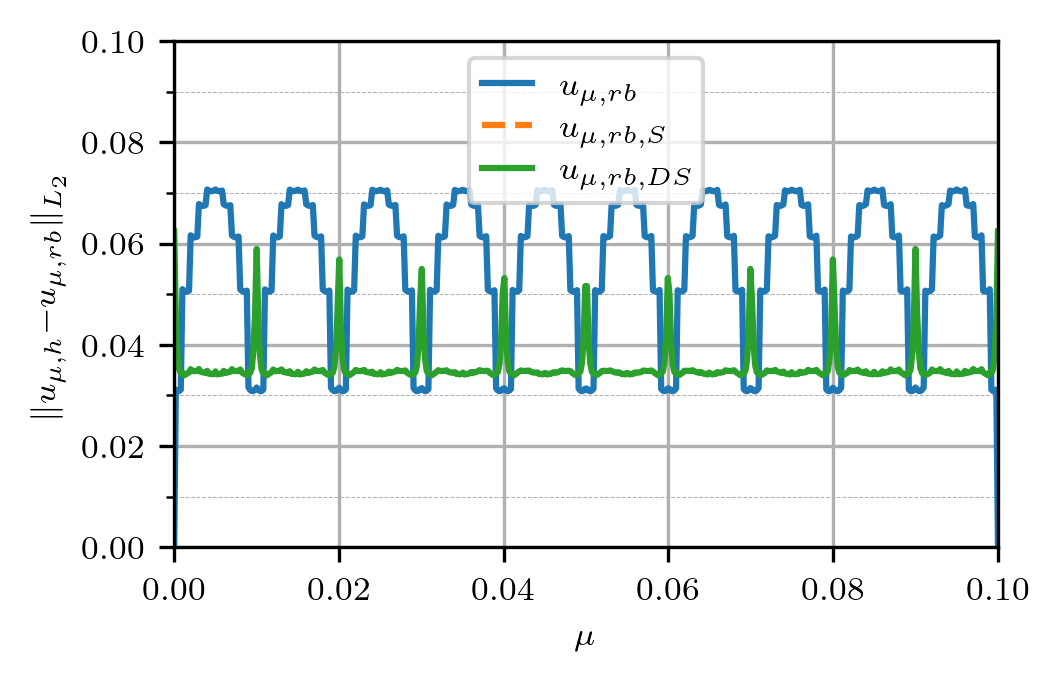

100
mean ROM: 0.192001
mean esROM: 0.181292 (5.5774%)
mean esROMs: 0.206546 (-7.5758%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.00583333, 1.14814815, 0.19080839, 0.18148506, 0.20629249, 8.1150
mean ROM: 0.190808
mean esROM: 0.181485 (5.5774%)
mean esROMs: 0.206292 (-7.5758%)


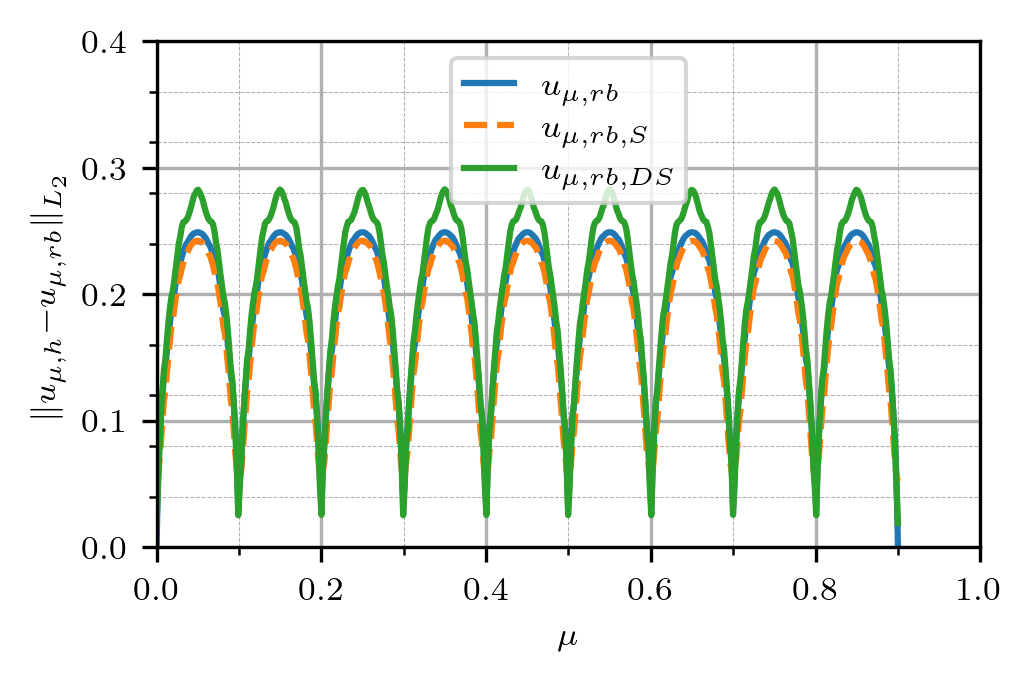

mean ROM: 0.056110
mean esROM: 0.058209 (-3.7409%)
mean esROMs: 0.019249 (65.6948%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00583333, 1.14814815, 0.05500465, 0.05812235, 0.01917566, -65.1381
mean ROM: 0.055005
mean esROM: 0.058122 (-3.7409%)
mean esROMs: 0.019176 (65.6948%)


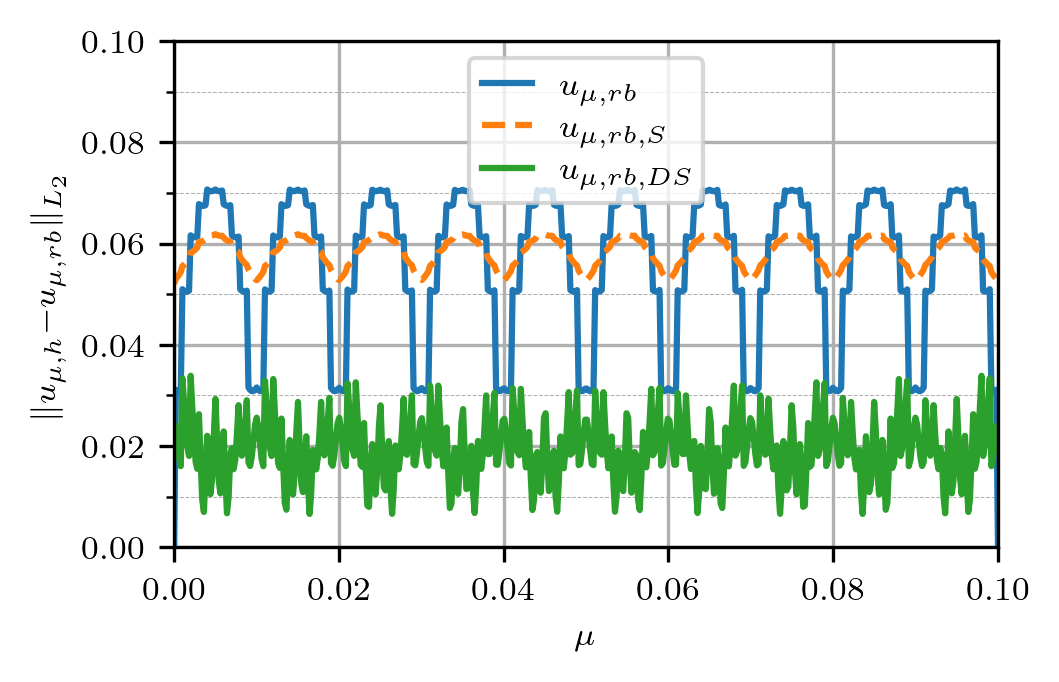

In [10]:
for i, rank in enumerate([10, 100]):
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    if rank == 10:
        parameters = np.array([0.05783333, 1.88888889])  # 0.03461111, 5.12345679  # 0.046817495544034825, 3.4777597632478527
    elif rank == 100:
        parameters = np.array([0.00583333, 1.14814815])  # 0.00627778, 0.55555556

    #parameters = optimize_hyperparameters(case)
    case["sigma"], case["c"] = parameters[0], parameters[1]
    for rank, ylim in zip([10, 100], (0.4, 0.1)):
        n_train = rank
        case["rank"] = rank
        case["n_train"] = n_train
        mu_train, X_train, X_train_s = make_training_data(case)
        mu_val = np.linspace(mu_train[0], mu_train[min(len(mu_train)-1, 10)], n_val)
        X_val, X_val_s = get_data_rw(mu_val, **case)
    
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
        X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)

        mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
            X_val, X_val_ROM, X_val_sROM, X_val_sROMs, norm=L2_error_rw, scaler=None
        )
        
    
        eROM = L2_error_rw(X_val_ROM, X_val)
        esROM = L2_error_rw(X_val_sROM, X_val)
        esROMs = L2_error_rw(X_val_sROMs, X_val)
        imp1 = 100 - np.mean(esROM) / np.mean(eROM) * 100
        imp2 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
        print("mean ROM: {:.6f}".format(np.mean(eROM)))
        print("mean esROM: {:.6f} ({:.4f}%)".format(np.mean(esROM), imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(np.mean(esROMs), imp2))

        print("double check:")
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        print("mean ROM: {:.6f}".format(mean_ROM))
        print("mean esROM: {:.6f} ({:.4f}%)".format(mean_sROM, imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(mean_sROMs, imp2))
    
        fig, ax = plt.subplots()
        ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
        ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
        ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, DS}$")
        plt.ylabel(r"$\|u_{\mu, h}{-u_{\mu, rb}}\|_{L_2}$")
        plt.xlabel(r"$\mu$")
        plt.legend()
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, ylim, 11, endpoint=True), minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        plt.xlim(0, 1)


        if len(mu_train) > 10:
            ax.set_xlim(mu_train[0], mu_train[10])
        ax.set_ylim(0, ylim)
        plt.savefig(pth+"S{:.0f}R{:.0f}.pdf".format(i+1, rank), bbox_inches='tight')
        plt.show()
    


In [ ]:
import copy
# Two column settings
panel_params = [
    {"name": "S1", "sigma": 0.05783333, "c": 1.88888889},
    {"name": "S2", "sigma": 0.00583333, "c": 1.14814815},
]

# Two row settings
ranks = [10, 100]
ylims = {10: 0.4, 100: 0.1}

fig, axs = plt.subplots(2, 2, figsize=(single_column_in * 2, single_column_in * 1.6), sharex=False)

for row, rank in enumerate(ranks):
    for col, pars in enumerate(panel_params):
        ax = axs[row, col]

        # Work on a local copy so the outer case is not mutated unexpectedly
        case_loc = copy.deepcopy(case)
        case_loc["rank"] = rank
        case_loc["n_train"] = rank
        case_loc["sigma"] = pars["sigma"]
        case_loc["c"] = pars["c"]

        # Data
        mu_train, X_train, X_train_s = make_training_data(case_loc)
        mu_val = np.linspace(mu_train[0], mu_train[min(len(mu_train) - 1, 10)], n_val)
        X_val, X_val_s = get_data_rw(mu_val, **case_loc)

        # Train ROMs
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)

        # Predict
        X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
        X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case_loc)

        # Errors
        eROM = L2_error_rw(X_val_ROM, X_val)
        esROM = L2_error_rw(X_val_sROM, X_val)
        esROMs = L2_error_rw(X_val_sROMs, X_val)

        imp1 = 100 - np.mean(esROM) / np.mean(eROM) * 100
        imp2 = 100 - np.mean(esROMs) / np.mean(eROM) * 100

        print(f"rank={rank}, sigma={pars['sigma']:.7f}, c={pars['c']:.7f}")
        print("mean ROM:    {:.6f}".format(np.mean(eROM)))
        print("mean esROM:  {:.6f} ({:.4f}%)".format(np.mean(esROM), imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(np.mean(esROMs), imp2))

        # Plot
        ax.plot(mu_val, eROM, "C0-",  label=r"$u_{\mu,rb}$")
        ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu,rb,S}$")
        ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu,rb,DS}$")

        ax.set_xlim(mu_train[0], mu_train[min(len(mu_train) - 1, 10)])
        ax.set_ylim(0, ylims[rank])

        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, ylims[rank], 11, endpoint=True), minor=True)
        ax.grid(True, which="minor", linestyle="--", lw=0.25)
        ax.grid(True, which="major", linestyle="-")

        # Column titles only on top row
        if row == 0:
            ax.set_title(rf"$\sigma_S = {pars['sigma']:.4f}$")

# Global axis labels
fig.supxlabel(r"$\mu$")
fig.supylabel(r"$\|u_{\mu,h} - u_{\mu,rb}\|_{L_2}$")

# Row labels
fig.text(0.02, 0.73, "rank 10\n(pre-asymptotic)", rotation=90,
         va="center", ha="center")
fig.text(0.02, 0.28, "rank 100\n(asymptotic)", rotation=90,
         va="center", ha="center")

# One shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0.06, 0.04, 1.0, 0.95])
plt.savefig(pth + "S1S2_rank10_rank100_2x2.pdf", bbox_inches="tight")
plt.show()

rank=10, sigma=0.0578333, c=1.8888889
mean ROM:    0.192001
mean esROM:  0.196510 (-2.3488%)
mean esROMs: 0.040759 (78.7714%)
